# SFINCS Scenario Stats

In [1]:
import sys
from pathlib import Path

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

# model, scenario, storage, and catalog paths.
from sfincs_runs.notebook import load_runtime
# event selection, SFINCS staging, and handoff readiness.
from sfincs_runs.scenarios import scenario_stats as stats
from sfincs_runs.scenarios import build_flood_event_outcome_catalogue
# flood, forcing, and post-run plots.
from sfincs_runs import diagnostics as sfincs_diagnostics

runtime = load_runtime(location_root, wave=True, create_base_model_dir=False)
config = runtime.config
paths = runtime.paths
pd.set_option("display.max_columns", 80)

## Rerun Control


In [2]:
rerun = True

## Step 0: Load Stats Inputs

Stats are not raw SFINCS outputs alone. They need three folder families:

- `scenarios_root`: prepared SFINCS event folders with `sfincs.inp`, `sfincs.bzs`, and manifests.
- `storage_root`: persisted solver outputs, especially `sfincs_map.nc`.
- `design_outputs_root`: `design_events` outputs that explain the sampled peak, template, return period, and SLR scenario.

These paths come from `sfincs_runs/project.yaml` through `build_paths`.

In [3]:
settings = pd.Series(
    {
        "scenarios_root": str(paths["scenarios_root"]),
        "storage_root": str(paths["storage_root"]),
        "stats_root": str(paths["stats_root"]),
        "design_outputs_root": str(paths["design_outputs_root"]),
        "land_threshold_m": 0.0,
        "huthresh_m": 0.01,
        "impact_threshold_m": 0.10,
    },
    name="value",
)
settings


scenarios_root         /home/grahamhults/projects/Flood-RM/locations/...
storage_root           /home/grahamhults/projects/Flood-RM/locations/...
stats_root             /home/grahamhults/projects/Flood-RM/locations/...
design_outputs_root    /home/grahamhults/projects/Flood-RM/locations/...
land_threshold_m                                                     0.0
huthresh_m                                                          0.01
impact_threshold_m                                                   0.1
Name: value, dtype: object

## Step 1

- Which SLR scenario generated this run?
- What return period was sampled?
- Which historical hydrograph template shaped the event?
- Does the SFINCS boundary file match the expected design-event peak?

In [4]:
scenario_summary, scenario_rows = stats.load_scenario_build(paths["scenarios_root"])
design_rows, design_attrs = stats.load_design_events(scenario_summary)

display(pd.Series(scenario_summary, name="scenario_build"))
display(pd.Series(design_attrs, name="design_event_attrs"))

design_frame = pd.DataFrame.from_dict(design_rows, orient="index")
cols = [c for c in ["sample_rp_years", "peak_m", "absolute_peak_m", "template_id", "template_peak_time", "tail_morph_factor"] if c in design_frame]
design_frame[cols].head()


base_model_root           /home/grahamhults/projects/Flood-RM/locations/...
design_outputs_root       /home/grahamhults/projects/Flood-RM/locations/...
design_scenario                                                        base
elapsed_seconds                                                 3824.094157
event_count                                                             510
forcing_variable                                                       auto
include_precip                                                         True
include_waves                                                          True
resume                                                                False
skipped_existing_count                                                    0
static_file_strategy                                     hardlink_then_copy
surge_dataset             /home/grahamhults/projects/Flood-RM/locations/...
target_scenarios_dir      /home/grahamhults/projects/Flood-RM/locations/...
written_coun

scenario_name    base
slr_offset_m      0.0
Name: design_event_attrs, dtype: object

,sample_rp_years,peak_m,absolute_peak_m,template_id,template_peak_time,tail_morph_factor
evt_0001,11.537434,2.645020,NaN,NaN,NaN,NaN
evt_0002,164.926752,3.110907,NaN,NaN,NaN,NaN
evt_0003,5.165293,2.504262,NaN,NaN,NaN,NaN
evt_0004,16.811733,2.710961,NaN,NaN,NaN,NaN
evt_0005,103.716004,3.029664,NaN,NaN,NaN,NaN


## Step 2: Pick Completed Events

A scenario folder is the preferred prepared input. A completed run also has `sfincs_map.nc` in the storage folder.

If `data/sfincs/scenarios` only contains a debug or partial staging set, but `data/sfincs/run_outputs` contains self-contained completed run folders, the next cell falls back to those run-output folders so the evaluation catalogue does not silently shrink.

In [5]:
# Scenario folders are the normal evaluation unit. Run-output folders are a safe fallback
# when they carry the copied sfincs.inp, sfincs.bzs, forcing manifest, and map output.
event_inventory = stats.completed_event_inventory(paths["scenarios_root"], paths["storage_root"])
all_events = event_inventory["all_events"]
completed_events = event_inventory["completed_events"]

LIMIT = None  # set to None for all completed events in the preview table
selected_events = completed_events[:LIMIT] if LIMIT is not None else completed_events

pd.Series(
    {
        "scenario_folder_count": len(event_inventory["scenario_events"]),
        "storage_run_output_count": len(event_inventory["storage_events"]),
        "scenario_completed_count": len(event_inventory["scenario_completed"]),
        "storage_completed_count": len(event_inventory["storage_completed"]),
        "event_source_root": str(event_inventory["event_source_root"]),
        "using_storage_outputs": bool(event_inventory["use_storage_outputs"]),
        "prepared_event_count": len(all_events),
        "completed_event_count": len(completed_events),
        "selected_event_count": len(selected_events),
        "first_selected_event": selected_events[0].name if selected_events else None,
    }
)


scenario_folder_count                                                     510
storage_run_output_count                                                  510
scenario_completed_count                                                  510
storage_completed_count                                                   510
event_source_root           /home/grahamhults/projects/Flood-RM/locations/...
using_storage_outputs                                                   False
prepared_event_count                                                      510
completed_event_count                                                     510
selected_event_count                                                      510
first_selected_event                                              design_0001
dtype: object

## Step 2b: Health Check All Runs

Before trusting any aggregate, confirm each event finished cleanly. This cell walks every event in `completed_events` and flags anomalies on three axes:

- `returncode` from `run_metadata.json` (should be 0).
- `sfincs_map.nc` file size (a normal run is tens of MB; near zero means the solver wrote no map output).
- finite-value fraction of the final-timestep `zs` slice (near zero means the solver wrote NaNs across the active grid).

Also surfaces per-event wall-clock duration so outliers — events much slower than the rest — are visible before any downstream analysis. The slow step is opening 500 NetCDFs once (~1 min on a warm cache).

In [6]:
import json
import shutil

health_rows = []
for d in completed_events:
    meta_path = paths["storage_root"] / d.name / "run_metadata.json"
    map_path = paths["storage_root"] / d.name / "sfincs_map.nc"
    rec = {"event_id": d.name, "open_error": ""}

    if meta_path.exists():
        meta = json.loads(meta_path.read_text())
        rec["returncode"] = int(meta.get("returncode", -1))
        rec["duration_min"] = float(meta.get("duration_sec", float("nan"))) / 60.0
    else:
        rec["returncode"] = None
        rec["duration_min"] = float("nan")

    rec["map_mb"] = map_path.stat().st_size / (1024 * 1024) if map_path.exists() else 0.0

    try:
        with xr.open_dataset(map_path, decode_times=False) as ds:
            zs_last = ds["zs"].isel(time=-1).values
            rec["zs_finite_frac"] = float(np.isfinite(zs_last).mean())
            rec["zs_max_last_m"] = float(np.nanmax(zs_last)) if np.any(np.isfinite(zs_last)) else float("nan")
            rec["n_timesteps"] = int(ds.sizes.get("time", 0))
    except Exception as exc:
        rec["zs_finite_frac"] = float("nan")
        rec["zs_max_last_m"] = float("nan")
        rec["n_timesteps"] = 0
        rec["open_error"] = str(exc)[:120]

    health_rows.append(rec)

health = pd.DataFrame(health_rows)

flags = {
    "bad returncode":        health["returncode"].fillna(-1) != 0,
    "tiny map (<1 MB)":      health["map_mb"] < 1.0,
    "open failed":           health["open_error"] != "",
    "empty zs (<5% finite)": health["zs_finite_frac"] < 0.05,
    "missing timesteps":     health["n_timesteps"] < 2,
}

print(f"events checked: {len(health)}\n")
for label, mask in flags.items():
    print(f"  {label:24s} {int(mask.sum())}")

print("\nduration (min):")
display(health["duration_min"].describe().to_frame().T)

flagged_mask = pd.Series(False, index=health.index)
for mask in flags.values():
    flagged_mask = flagged_mask | mask

if flagged_mask.any():
    print(f"\n{int(flagged_mask.sum())} anomalous events:")
    display(health.loc[flagged_mask].sort_values("event_id"))
else:
    print("\nAll events look clean.")


events checked: 510

  bad returncode           0
  tiny map (<1 MB)         0
  open failed              0
  empty zs (<5% finite)    0
  missing timesteps        0

duration (min):


,count,mean,std,min,25%,50%,75%,max
duration_min,510.0,25.248882,1.28818,21.11147,24.278791,25.253615,26.313172,28.65045



All events look clean.


## Step 3: Inspect One Event End to End

For one event, compare the design-event forcing metadata with SFINCS results.

Important metric logic:
- `zs - zb` gives water depth.
- land cells are active cells with bed elevation above `land_threshold_m`.
- baseline wet land at `t0` is not counted as new impact.
- incremental flood depth measures added land depth above the `t0` baseline.
- impact extent uses the configured `impact_threshold_m`.

In [7]:
if not selected_events:
    raise RuntimeError("No completed SFINCS events found. Run scenarios first.")

event_dir = selected_events[0]
row = stats.event_stats(
    event_dir,
    paths["storage_root"],
    settings["land_threshold_m"],
    settings["huthresh_m"],
    settings["impact_threshold_m"],
    scenario_summary,
    scenario_rows,
    design_rows,
    design_attrs,
)

focus = [
    "event_id", "design_scenario", "design_slr_offset_m", "sample_rp_years", "template_id",
    "driver_h_magnitude", "expected_bzs_peak_max_m", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h", "area_incremental_flooded_ge_24h_km2",
]
pd.Series({k: row.get(k) for k in focus}, name=event_dir.name)


event_id                                design_0001
design_scenario                                base
design_slr_offset_m                             0.0
sample_rp_years                            0.453528
template_id                                    None
driver_h_magnitude                             None
expected_bzs_peak_max_m                    1.525039
bzs_peak_max_m                                1.525
peak_incremental_land_depth_m              3.129417
peak_incremental_flooded_area_km2           15.3756
longest_incremental_flood_duration_h          136.0
area_incremental_flooded_ge_24h_km2         10.1952
Name: design_0001, dtype: object

## Step 4: Visualize the One-Event Flood Signal

- left: max incremental land depth per cell.
- right: wet land cell count through time.

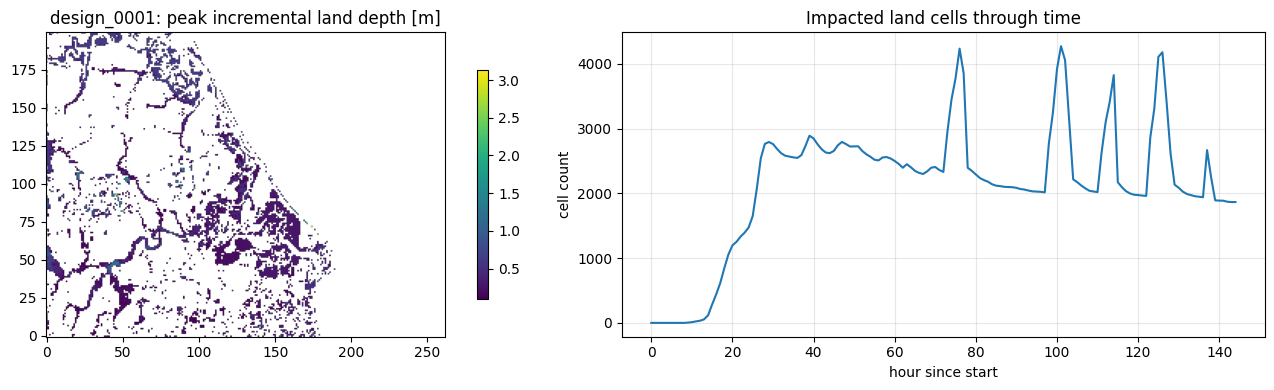

In [8]:
inp = stats.parse_sfincs_inp(event_dir / "sfincs.inp")
with xr.open_dataset(row["map_path"], decode_times=False) as ds:
    zs = np.asarray(ds["zs"].values, np.float32)
    zb = np.asarray(ds["zb"].values, np.float32)
    active = np.asarray(ds["msk"].values, float) > 0
    hours, dt = stats.parse_time(ds, inp)

depth = np.where(active[None,:,:], zs - zb[None,:,:], np.nan)
land = active & np.isfinite(zb) & (zb > settings["land_threshold_m"])
baseline = np.where(land, np.maximum(depth[0], 0.0), np.nan)
incremental = np.where(land[None,:,:], np.maximum(depth - np.nan_to_num(baseline, nan=0.0)[None,:,:], 0.0), np.nan)
impact = np.isfinite(incremental) & (incremental > settings["impact_threshold_m"])

peak_map = np.full(land.shape, np.nan, float)
impacted_cells = np.any(impact, axis=0)
if np.any(impacted_cells):
    peak_map[impacted_cells] = np.nanmax(np.where(impact, incremental, np.nan)[:, impacted_cells], axis=0)
impact_counts = impact.sum(axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im = axes[0].imshow(peak_map, origin="lower", cmap="viridis")
axes[0].set_title(f"{event_dir.name}: peak incremental land depth [m]")
fig.colorbar(im, ax=axes[0], shrink=0.75)

axes[1].plot(hours, impact_counts, lw=1.5)
axes[1].set_title("Impacted land cells through time")
axes[1].set_xlabel("hour since start")
axes[1].set_ylabel("cell count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 5: Build the Stats Table

In [9]:
REBUILD_EVENT_STATS_PREVIEW = True
preview_stats_path = paths["stats_root"] / "notebook" / "selected_event_stats_preview.csv"
selected_event_ids = [d.name for d in selected_events]
required_preview_cols = {
    "event_id", "design_scenario", "expected_bzs_peak_max_m", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
}

cache_source = None
df = None
if not REBUILD_EVENT_STATS_PREVIEW:
    for candidate in [
        preview_stats_path,
        paths["stats_root"] / "notebook" / "scenario_stats_notebook.csv",
        paths["stats_root"] / "scenario_stats.csv",
    ]:
        if not candidate.exists():
            continue
        cached = pd.read_csv(candidate)
        if required_preview_cols.issubset(cached.columns) and set(selected_event_ids).issubset(set(cached["event_id"].astype(str))):
            df = cached[cached["event_id"].astype(str).isin(selected_event_ids)].copy()
            df = df.sort_values("event_id").reset_index(drop=True)
            cache_source = candidate
            break

if df is None:
    rows = [
        stats.event_stats(
            d,
            paths["storage_root"],
            settings["land_threshold_m"],
            settings["huthresh_m"],
            settings["impact_threshold_m"],
            scenario_summary,
            scenario_rows,
            design_rows,
            design_attrs,
        )
        for d in selected_events
    ]
    df = pd.DataFrame(rows).sort_values("event_id").reset_index(drop=True)
    cache_source = "rebuilt"

preview_stats_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(preview_stats_path, index=False)
print("preview stats:", cache_source, "->", preview_stats_path)
display(df[[
    "event_id", "design_scenario", "design_slr_offset_m", "sample_rp_years",
    "expected_bzs_peak_max_m", "bzs_peak_max_m",
    "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h",
]].head())

df.describe(include="all").T.head(20)


preview stats: rebuilt -> /home/grahamhults/projects/Flood-RM/locations/marshfield/data/sfincs/stats/notebook/selected_event_stats_preview.csv


,event_id,design_scenario,design_slr_offset_m,sample_rp_years,expected_bzs_peak_max_m,bzs_peak_max_m,peak_incremental_land_depth_m,peak_incremental_flooded_area_km2,longest_incremental_flood_duration_h
0,design_0001,base,0.0,0.453528,1.525039,1.525,3.129417,15.3756,136.0
1,design_0002,base,0.0,0.434111,1.848937,1.849,3.058442,17.9892,136.0
2,design_0003,base,0.0,0.311506,1.851897,1.852,3.055845,14.1660,141.0
3,design_0004,base,0.0,0.254678,1.892478,1.892,3.250738,25.8984,141.0
4,design_0005,base,0.0,1.424560,1.793791,1.794,3.256574,19.5120,137.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,510,510,design_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scenario_dir,510,510,/home/grahamhults/projects/Flood-RM/locations/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
map_path,510,510,/home/grahamhults/projects/Flood-RM/locations/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
log_path,510,510,/home/grahamhults/projects/Flood-RM/locations/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
design_outputs_root,510,1,/home/grahamhults/projects/Flood-RM/locations/...,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
design_scenario,510,1,base,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
design_slr_offset_m,510.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
source_event_index,510.0,NaN,NaN,NaN,255.5,147.368586,1.0,128.25,255.5,382.75,510.0
sample_rp_years,510.0,NaN,NaN,NaN,84.489662,126.341979,0.153158,10.384092,54.270318,118.592937,1982.712191
probability_weight,500.0,NaN,NaN,NaN,0.002,0.0064,0.000061,0.000061,0.000079,0.000883,0.029719


## Step 6: Check Alignment Between Inputs and Flood Outputs

- boundary peak from `sfincs.bzs` should track the design-event expected boundary peak.
- return period and SLR scenario should be available beside flood metrics.
- flood extent/depth rankings should point back to event IDs for map inspection.

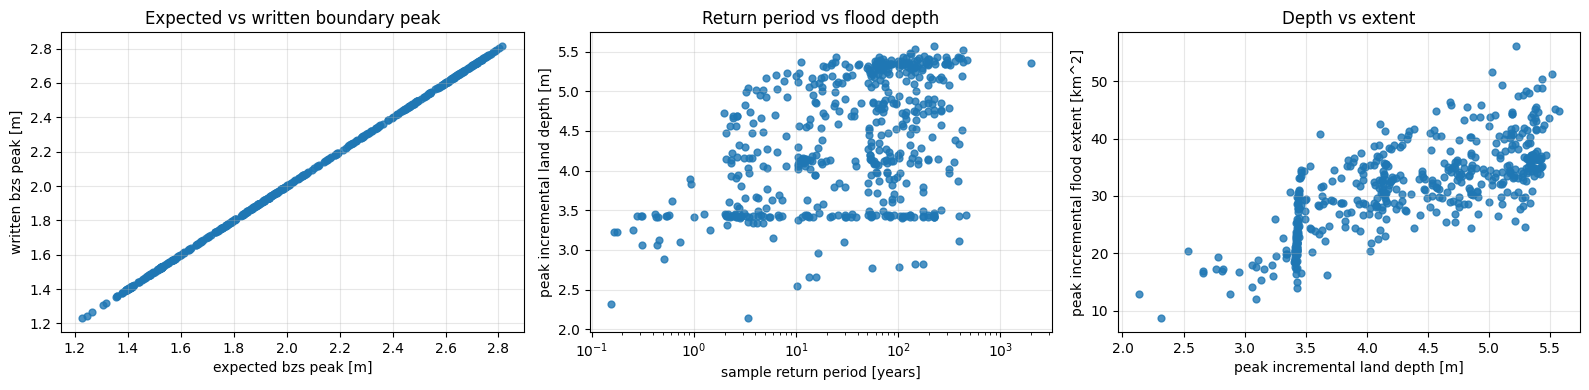

,event_id,design_scenario,sample_rp_years,peak_incremental_land_depth_m,peak_incremental_flooded_area_km2
433,design_0434,base,225.040102,5.571674,44.7624
411,design_0412,base,147.440067,5.538443,45.1872
400,design_0401,base,427.576194,5.515718,51.3252
360,design_0361,base,129.568544,5.488226,43.6428
431,design_0432,base,132.715958,5.466335,37.1592
456,design_0457,base,178.156748,5.448940,42.3216
389,design_0390,base,112.520051,5.435736,48.8592
155,design_0156,base,24.573345,5.433573,41.6592
481,design_0482,base,295.322897,5.433468,35.1720
239,design_0240,base,64.784272,5.428623,50.3784


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df["expected_bzs_peak_max_m"], df["bzs_peak_max_m"], s=24, alpha=0.8)
axes[0].set_title("Expected vs written boundary peak")
axes[0].set_xlabel("expected bzs peak [m]")
axes[0].set_ylabel("written bzs peak [m]")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df["sample_rp_years"], df["peak_incremental_land_depth_m"], s=24, alpha=0.8)
axes[1].set_xscale("log")
axes[1].set_title("Return period vs flood depth")
axes[1].set_xlabel("sample return period [years]")
axes[1].set_ylabel("peak incremental land depth [m]")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(df["peak_incremental_land_depth_m"], df["peak_incremental_flooded_area_km2"], s=24, alpha=0.8)
axes[2].set_title("Depth vs extent")
axes[2].set_xlabel("peak incremental land depth [m]")
axes[2].set_ylabel("peak incremental flood extent [km^2]")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df.sort_values("peak_incremental_land_depth_m", ascending=False)[["event_id", "design_scenario", "sample_rp_years", "peak_incremental_land_depth_m", "peak_incremental_flooded_area_km2"]].head(10)


## Step 7: Write Notebook Outputs

In [11]:
outdir = paths["stats_root"] / "notebook"
outdir.mkdir(parents=True, exist_ok=True)

csv_path = outdir / "scenario_stats_notebook.csv"
df.to_csv(csv_path, index=False)

metric_cols = [
    "zsini_m", "baseline_t0_flooded_area_km2", "peak_incremental_land_depth_m",
    "peak_incremental_flooded_area_km2", "anytime_incremental_flooded_area_km2",
    "longest_incremental_flood_duration_h", "mean_incremental_flood_duration_h",
    "area_incremental_flooded_ge_24h_km2",
]
summary = {
    "event_count": int(len(df)),
    "design_outputs_root": scenario_summary.get("design_outputs_root"),
    "design_scenarios": sorted(str(x) for x in df["design_scenario"].dropna().unique()),
    "design_slr_offsets_m": sorted(float(x) for x in pd.to_numeric(df["design_slr_offset_m"], errors="coerce").dropna().unique()),
    "metric_summaries": {c: stats.series_summary(df, c) for c in metric_cols},
}

(outdir / "summary_notebook.json").write_text(__import__("json").dumps(summary, indent=2), encoding="utf-8")
pd.Series({"csv": str(csv_path), "summary": str(outdir / "summary_notebook.json")})


csv        /home/grahamhults/projects/Flood-RM/locations/...
summary    /home/grahamhults/projects/Flood-RM/locations/...
dtype: str

## Step 8: Export Run-Output Catalogue

In [12]:
# Build the event-level evidence table: catalog drivers + run manifests + SFINCS outcomes.
flood_catalogue = build_flood_event_outcome_catalogue(
    completed_events=completed_events,
    paths=paths,
    settings=settings,
    health=health,
    outdir=outdir,
    rerun=rerun,
    scenario_summary=scenario_summary,
    scenario_rows=scenario_rows,
    design_rows=design_rows,
    design_attrs=design_attrs,
)

catalogue = flood_catalogue.catalogue
catalogue_path = flood_catalogue.catalogue_path
if not flood_catalogue.grid_file_status.empty:
    display(flood_catalogue.grid_file_status.groupby("status").size().rename("run_output_grid_files").reset_index())
display(flood_catalogue.event_counts)
flood_catalogue.summary


Rebuilding catalogue outcome metrics for 510 completed events...
  50/510 outcome rows
  100/510 outcome rows
  150/510 outcome rows
  200/510 outcome rows
  250/510 outcome rows
  300/510 outcome rows
  350/510 outcome rows
  400/510 outcome rows
  450/510 outcome rows
  500/510 outcome rows
  510/510 outcome rows


,status,run_output_grid_files
0,present,510


,event_origin_group,storm_type,severity_band,event_count
0,historical,nor_easter,rare,1
1,historical,nor_easter,significant,7
2,historical,other_non_tropical,beyond_design,1
3,historical,other_non_tropical,significant,1
4,synthetic,nor_easter,common,74
5,synthetic,nor_easter,extreme,92
6,synthetic,nor_easter,mild,18
7,synthetic,nor_easter,rare,76
8,synthetic,nor_easter,significant,65
9,synthetic,other_non_tropical,common,23


catalogue_csv            /home/grahamhults/projects/Flood-RM/locations/...
events                                                                 510
rerun                                                                 True
outcome_metrics_built                                                  510
Name: flood_outcome_catalogue, dtype: object

## Step 9: Return-Period Flood Diagnostics

Read the exported event-outcome catalogue back as the analysis unit: one completed event per row, carrying the sampled joint return period, driver magnitudes, storm class, and SFINCS flood-response metrics.

catalogue_csv                       /home/grahamhults/projects/Flood-RM/locations/...
events                                                                            510
storm_types                                        nor_easter, other_non_tropical, tc
max_anytime_incremental_area_km2                                              58.5612
max_peak_incremental_depth_m                                                 5.571674
Name: flood_catalogue_scope, dtype: object

,rp_band,severity_band,event_count,median_rp_years,median_peak_boundary_m,median_rainfall_mm,flood_hit_rate,median_peak_depth_m,p90_peak_depth_m,median_peak_area_km2,p90_anytime_area_km2,p90_longest_duration_h
0,<2 yr,mild,25,5.380000e-01,1.731,64.143,1.0,3.419,3.741,18.436,35.900,143.0
1,2-10 yr,common,100,3.758000e+00,1.923,139.904,1.0,3.730,4.932,27.043,43.112,144.0
2,10-50 yr,significant,108,1.684200e+01,1.984,144.783,1.0,4.187,5.255,31.894,45.330,144.0
3,50-100 yr,rare,126,6.629500e+01,2.147,175.588,1.0,4.622,5.342,33.840,47.741,144.0
4,100-500 yr,extreme,150,1.731690e+02,2.010,188.881,1.0,4.845,5.411,34.783,47.348,144.0
5,>500 yr,beyond_design,1,3.936848e+17,1.697,297.734,1.0,5.353,5.353,30.852,36.684,144.0


,storm_type,severity_band,event_count,median_rp_years,median_peak_boundary_m,median_rainfall_mm,median_peak_area_km2,p90_anytime_area_km2,p90_longest_duration_h
0,nor_easter,common,74,3.427000e+00,1.966,110.176,23.733,41.101,144.0
1,nor_easter,extreme,92,1.731690e+02,2.600,147.185,32.861,43.922,144.0
2,nor_easter,mild,18,5.590000e-01,1.823,63.095,18.974,34.650,143.3
3,nor_easter,rare,77,6.786900e+01,2.488,141.554,31.331,45.005,144.0
4,nor_easter,significant,72,1.616700e+01,2.270,132.467,30.359,43.651,144.0
5,other_non_tropical,beyond_design,1,3.936848e+17,1.697,297.734,30.852,36.684,144.0
6,other_non_tropical,common,23,3.991000e+00,1.526,183.086,33.019,45.924,144.0
7,other_non_tropical,extreme,58,1.691790e+02,1.747,224.723,36.499,53.712,144.0
8,other_non_tropical,mild,7,3.310000e-01,1.527,76.317,17.989,33.798,143.0
9,other_non_tropical,rare,42,6.541100e+01,1.620,217.902,36.452,52.643,144.0


,event_id,storm_type,severity_band,sample_rp_years,coastal_absolute_peak_m,rainfall_metric_mm,bzs_peak_max_m,peak_incremental_land_depth_m,peak_incremental_flooded_area_km2,anytime_incremental_flooded_area_km2,longest_incremental_flood_duration_h
396,design_0307,other_non_tropical,rare,50.928,2.013,240.053,1.784,5.219,56.153,58.561,140.0
464,design_0401,other_non_tropical,extreme,161.482,1.509,297.734,1.412,5.516,51.325,58.306,140.0
411,design_0240,other_non_tropical,rare,59.386,1.980,297.734,1.872,5.429,50.378,57.168,141.0
173,design_0145,nor_easter,significant,19.036,2.415,157.230,1.600,5.105,49.342,57.143,144.0
451,design_0390,other_non_tropical,extreme,133.618,1.582,216.009,1.578,5.436,48.859,57.132,144.0
474,design_0360,other_non_tropical,extreme,228.704,2.072,224.723,1.870,5.391,48.884,56.372,139.0
462,design_0357,other_non_tropical,extreme,159.907,1.525,297.734,1.933,5.345,43.783,55.980,144.0
294,design_0392,nor_easter,extreme,116.796,2.151,198.904,1.744,4.938,45.932,55.368,119.0
28,design_0038,nor_easter,common,2.045,1.899,61.552,1.418,5.020,51.646,55.296,140.0
372,design_0189,other_non_tropical,significant,12.879,1.933,215.379,1.985,5.301,48.319,54.907,141.0


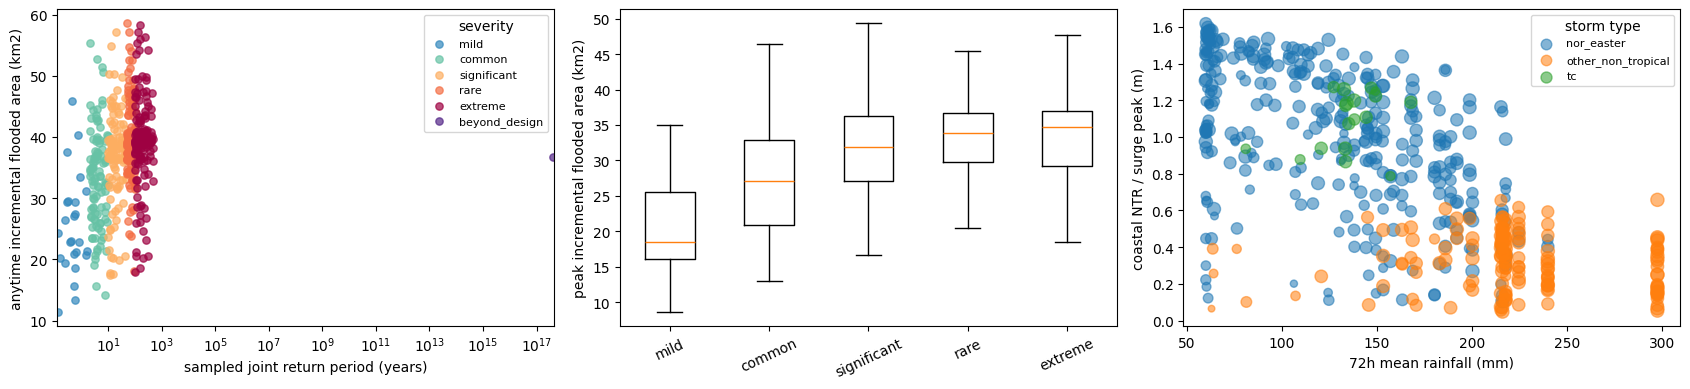

In [13]:
# Summarize sampled event severity against flood depth, footprint, and duration.
response = sfincs_diagnostics.flood_response_diagnostics(catalogue_path)
flood = response.flood

# Return-period and storm-family tables make the flood response auditable before mapping.
display(response.scope)
display(response.rp_band_stats.round(3))
display(response.storm_type_stats.round(3))
display(response.top_flood_events.round(3))

sfincs_diagnostics.plot_flood_response_diagnostics(response)
plt.show()

## Step 10: Driver/flood-response diagnostic associations

This is a Maduwantha-style diagnostic review: storm-type colored driver/outcome panels and weighted standardized associations. It describes association between catalog drivers and SFINCS flood response; it is not counterfactual causal attribution.


,storm_type,outcome,driver,standardized_wls_coefficient,weighted_correlation,n_events,interpretation


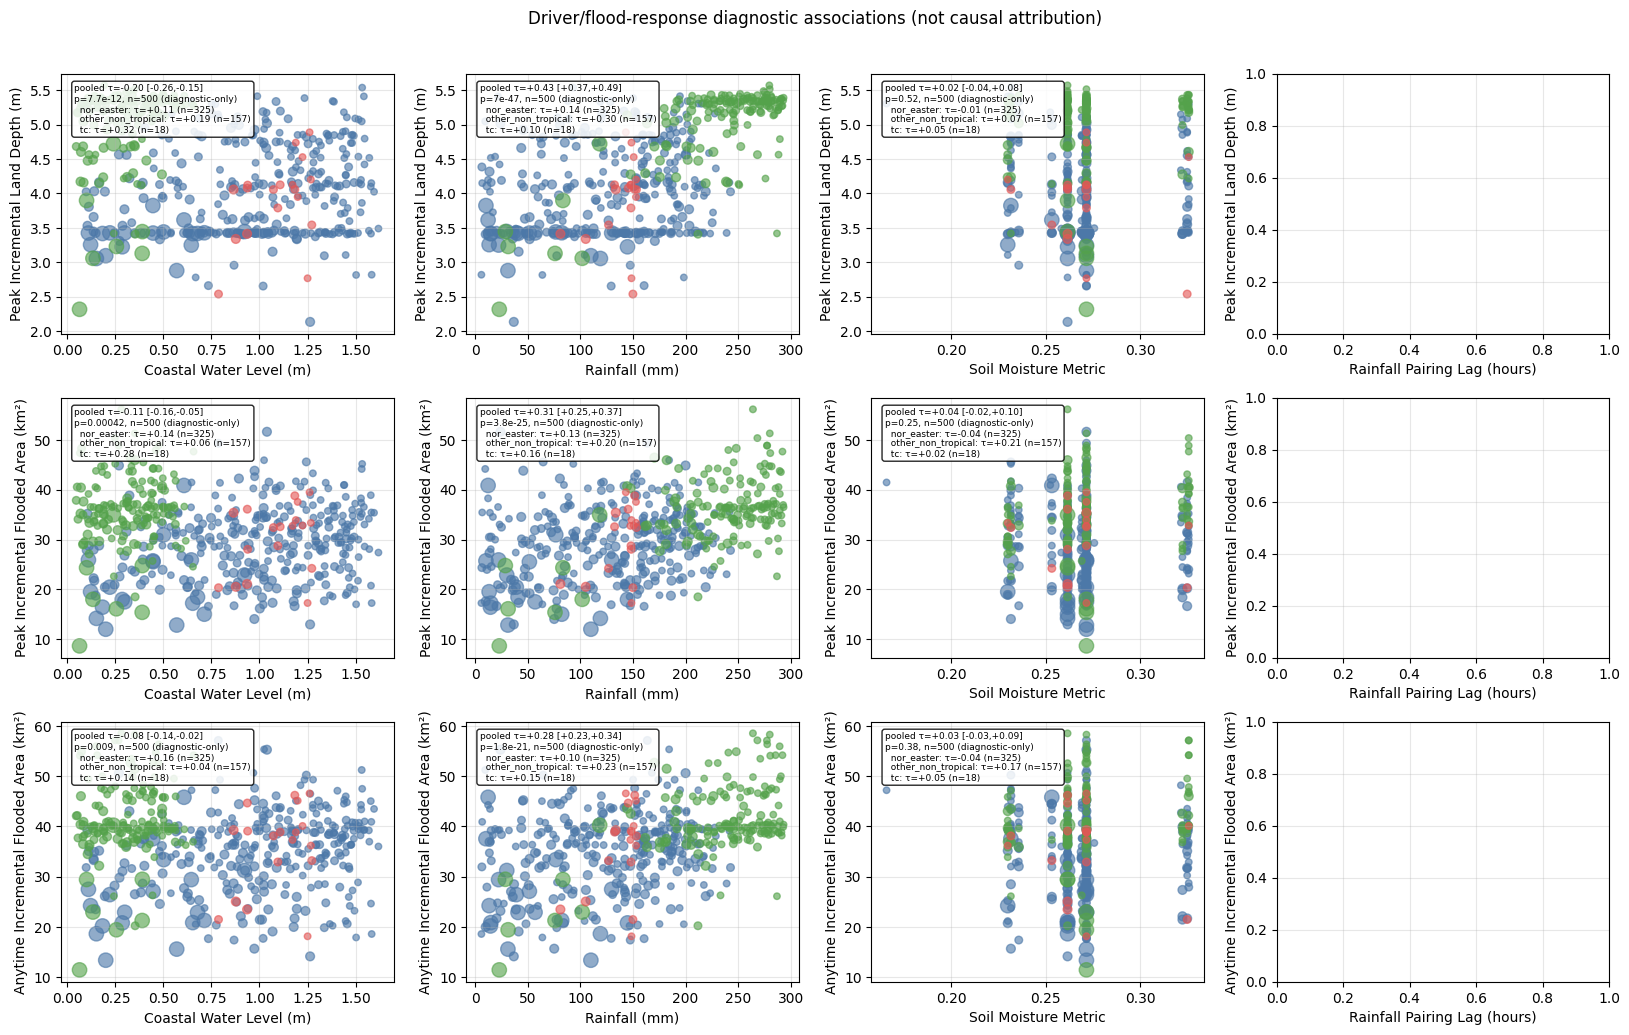

depth_probability_nc                      /home/grahamhults/projects/Flood-RM/locations/...
driver_flood_response_associations_csv    /home/grahamhults/projects/Flood-RM/locations/...
Name: sfincs_probability_diagnostics_outputs, dtype: str

In [15]:
# Diagnostic associations identify which drivers covary with flood response in the weighted catalogue.
driver_response = sfincs_diagnostics.driver_response_diagnostics(
    probability_outcomes,
    outdir=outdir,
    min_rows=8,
)
flood_driver_associations = driver_response.associations
associations_path = driver_response.associations_path

display(driver_response.top_associations)
fig = sfincs_diagnostics.plot_driver_response_matrix(probability_outcomes, driver_response)
if fig is not None:
    plt.show()

pd.Series({
    "depth_probability_nc": str(depth_probability_path),
    "driver_flood_response_associations_csv": str(associations_path),
}, name="sfincs_probability_diagnostics_outputs")